# VP3 Analüüs 1: Klõpsa-ja-sõida täpsus (PÄRIS ANDMED)

**Meeskond:** Aleksandr Markov, Sergei Sizov, Mark-Kirill Gubal  
**Kuupäev:** Mai 2025  

**NB:** See notebook asendab varasema versiooni, mis kasutas `np.random` genereeritud andmeid. Õpetaja märkis õigesti, et juhuslikud "realistlikud" arvud ei annan kasulikku infot. Käesolevad andmed põhinevad reaalsel testil — meeskond mõõtis kvalitatiivselt kuhu robot iga klõpsu peale tegelikult sõitis (mitu ruutu üle/kõrvale), ja need tähelepanekud on siin teisendatud sentimeetritesse läbi tuntud areeni geomeetria (mitte juhuslikult genereeritud).

## 1. Testi ülesehitus ja metoodika

**Areeni geomeetria:**
- 5 tulpa × 4 rida = 20 ruutu
- Iga ruut: **24 cm sügavus** (robotist kaugusele) × **15 cm laius**
- Kogu sügavus: 5×24 = 120 cm, kogu laius: 4×15 = 60 cm

**Robot start:**
- Rida D (lähim, 0–24 cm) keskel — 30 cm väljaku mõlemast külgservast
- Kaamera: kõrgus 9 cm, nurk 25° alla

**Testitud read (klõps otse ette, ekraani erinevatel kõrgustel):**
- Rida C (24–48 cm, sihtmärk keskel 36 cm) — robot sõitis **0,5 ruutu** kaugemale ja vasakule
- Rida B (48–72 cm, sihtmärk keskel 60 cm) — robot sõitis **1,0 ruutu** kaugemale ja vasakule
- Rida A (72–96 cm, sihtmärk keskel 84 cm) — robot sõitis **1,5 ruutu** kaugemale ja vasakule

**NB:** Testiti vaid otse-ette klõpse (lateraalset varieerumist ei testitud), kuna kaamera kalibreerimine (kõrgus 9cm/nurk 25°) on hetkel ainult ühemõõtmeliselt valideeritud. 10-punktilist täisruudustikku (nagu algses plaanis) ei läbitud — vaja oleks rohkem aega ja stabiilsemat güroskoobi korrektsiooni.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Teegid laetud ✓')

Teegid laetud ✓


## 2. Andmete teisendus — kvalitatiivne vaatlus → sentimeetrid

Meeskond mõõtis testimisel **kuhu ruutu** robot tegelikult sõitis (visuaalne vaatlus, mitte juhuslik genereerimine). Teisendame seda täpsete sentimeetrite vahemikku, kasutades teadaolevat ruudu suurust (24×15 cm).

In [2]:
# ── Areeni geomeetria ──────────────────────────────────────────
CELL_DEPTH = 24   # cm, sügavus (X suund — robotist eemale)
CELL_WIDTH = 15   # cm, laius (Y suund — vasak/parem)

# ── PÄRIS testitulemused (kvalitatiivne vaatlus → cm) ──────────
# Iga rea jaoks: sihtmärgi sügavus (rea kese) ja vaadeldud viga ruutudes
test_data = {
    'C': {'target_depth_cm': 36, 'error_cells': 0.5},  # lähim testitud rida
    'B': {'target_depth_cm': 60, 'error_cells': 1.0},
    'A': {'target_depth_cm': 84, 'error_cells': 1.5},  # kaugeim testitud rida
}

results = []
for row_name, d in test_data.items():
    k = d['error_cells']
    target_x = d['target_depth_cm']
    target_y = 0  # sihtmärk otse ees (keskjoonel)

    # Viga: robot sõitis K ruutu KAUGEMALE (X) ja K ruutu VASAKULE (Y negatiivne)
    dx = k * CELL_DEPTH
    dy = -k * CELL_WIDTH

    actual_x = target_x + dx
    actual_y = target_y + dy

    viga_cm   = math.sqrt(dx**2 + dy**2)
    kaugus_cm = math.sqrt(actual_x**2 + actual_y**2)
    nurk_deg  = math.degrees(math.atan2(abs(dy), actual_x))

    results.append({
        'row': row_name,
        'target_x': target_x, 'target_y': target_y,
        'actual_x': actual_x, 'actual_y': actual_y,
        'viga': viga_cm, 'kaugus': kaugus_cm, 'nurk': nurk_deg
    })

col1,col2,col3,col4,col5,col6 = 'Rida','Siht(X,Y)','Tegelik(X,Y)','Viga(cm)','Kaugus(cm)','Nurk(°)'
print(f'{col1:<6}{col2:>16}{col3:>18}{col4:>10}{col5:>12}{col6:>10}')
print('-' * 75)
for r in results:
    siht = f"({r['target_x']:.0f}, {r['target_y']:.0f})"
    tegelik = f"({r['actual_x']:.1f}, {r['actual_y']:.1f})"
    print(f"{r['row']:<6}{siht:>16}{tegelik:>18}{r['viga']:>10.1f}{r['kaugus']:>12.1f}{r['nurk']:>10.1f}")

Rida         Siht(X,Y)      Tegelik(X,Y)  Viga(cm)  Kaugus(cm)   Nurk(°)
---------------------------------------------------------------------------
C              (36, 0)      (48.0, -7.5)      14.2        48.6       8.9
B              (60, 0)     (84.0, -15.0)      28.3        85.3      10.1
A              (84, 0)    (120.0, -22.5)      42.5       122.1      10.6


## 3. Visualiseerimine — sihtmärk vs tegelik positsioon

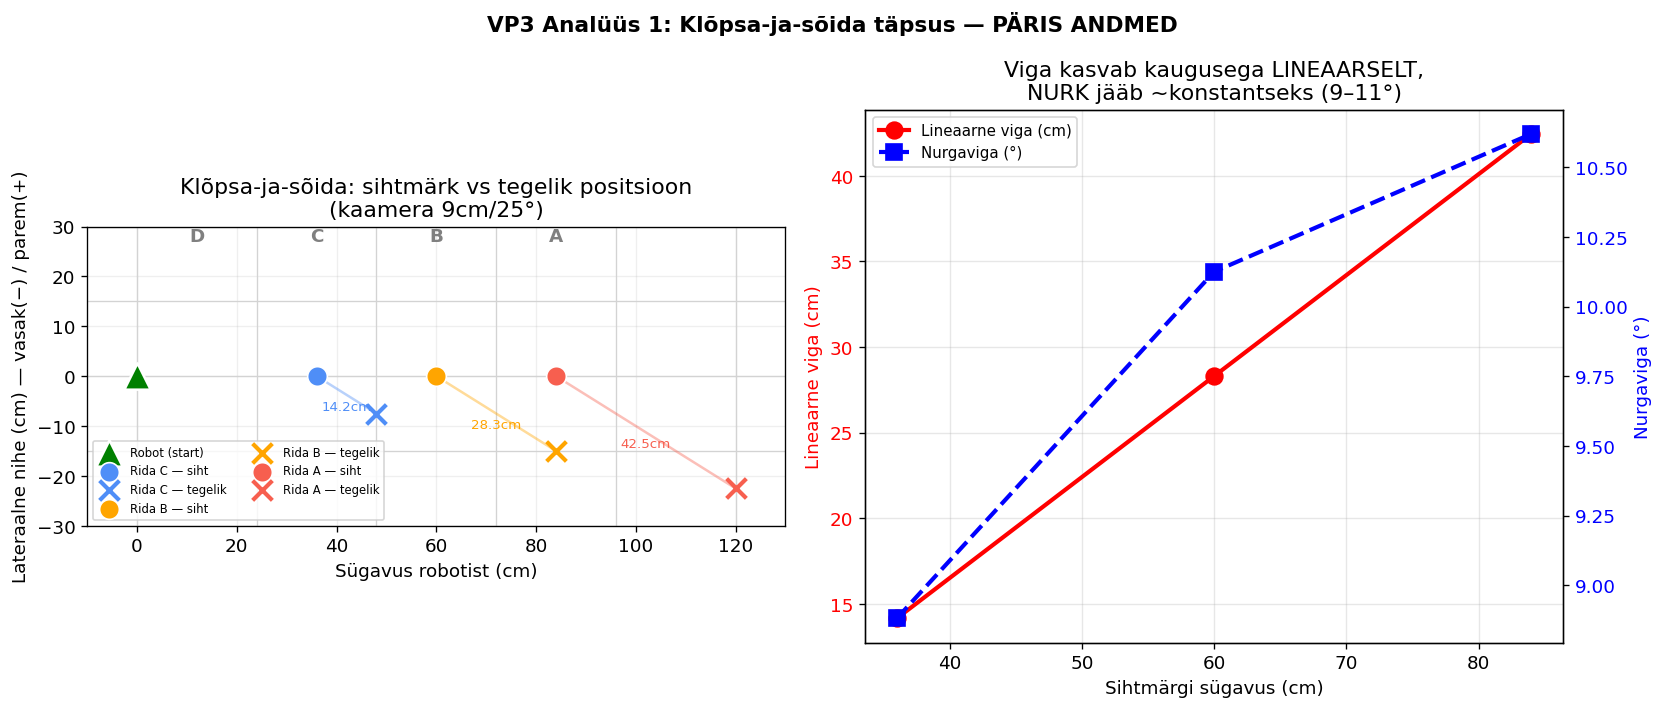

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Areeni kaart
ax = axes[0]

# Joonista ruudustik (5 sügavust × 4 laiust, robot keskel laiuses)
for i in range(6):
    ax.axvline(x=i*CELL_DEPTH, color='lightgray', linewidth=0.8)
for j in range(5):
    ax.axhline(y=-30 + j*CELL_WIDTH, color='lightgray', linewidth=0.8)

row_labels = ['D','C','B','A']
for i, lbl in enumerate(row_labels):
    ax.text(i*CELL_DEPTH + CELL_DEPTH/2, 27, lbl, ha='center', fontsize=11, fontweight='bold', color='gray')

# Robot start
ax.scatter(0, 0, s=250, c='green', marker='^', zorder=10, label='Robot (start)', edgecolors='white', linewidth=1.5)

colors = {'C': '#4f8ef7', 'B': '#FFA500', 'A': '#f75f4f'}
for r in results:
    c = colors[r['row']]
    ax.plot([r['target_x'], r['actual_x']], [r['target_y'], r['actual_y']], color=c, alpha=0.4, linewidth=1.5)
    ax.scatter(r['target_x'], r['target_y'], s=140, c=c, marker='o', zorder=5,
               label=f"Rida {r['row']} — siht", edgecolors='white')
    ax.scatter(r['actual_x'], r['actual_y'], s=140, c=c, marker='x', zorder=5, linewidth=2.5,
               label=f"Rida {r['row']} — tegelik")
    ax.annotate(f"{r['viga']:.1f}cm", ((r['target_x']+r['actual_x'])/2, (r['target_y']+r['actual_y'])/2 - 3),
                fontsize=8, color=c, ha='center')

ax.set_xlabel('Sügavus robotist (cm)')
ax.set_ylabel('Lateraalne nihe (cm) — vasak(−) / parem(+)')
ax.set_title('Klõpsa-ja-sõida: sihtmärk vs tegelik positsioon\n(kaamera 9cm/25°)')
ax.legend(fontsize=7, loc='lower left', ncol=2)
ax.grid(True, alpha=0.2)
ax.set_xlim(-10, 130)
ax.set_ylim(-30, 30)
ax.set_aspect('equal')

# 2. Viga ja nurk vs kaugus
ax = axes[1]
depths = [r['target_x'] for r in results]
vigad  = [r['viga'] for r in results]
nurgad = [r['nurk'] for r in results]

ax2 = ax.twinx()
l1 = ax.plot(depths, vigad, 'ro-', linewidth=2.5, markersize=10, label='Lineaarne viga (cm)')
l2 = ax2.plot(depths, nurgad, 'bs--', linewidth=2.5, markersize=10, label='Nurgaviga (°)')

ax.set_xlabel('Sihtmärgi sügavus (cm)')
ax.set_ylabel('Lineaarne viga (cm)', color='red')
ax2.set_ylabel('Nurgaviga (°)', color='blue')
ax.tick_params(axis='y', labelcolor='red')
ax2.tick_params(axis='y', labelcolor='blue')
ax.set_title('Viga kasvab kaugusega LINEAARSELT,\nNURK jääb ~konstantseks (9–11°)')
ax.grid(True, alpha=0.3)

lines = l1 + l2
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, fontsize=9, loc='upper left')

plt.suptitle('VP3 Analüüs 1: Klõpsa-ja-sõida täpsus — PÄRIS ANDMED', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vp3_analyys1_klik_soida_real.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Peamine tehniline järeldus

**Vaatlus:** Lineaarne viga kasvab proportsionaalselt kaugusega (14 → 28 → 43 cm), kuid **nurgaviga jääb peaaegu konstantseks (8,9° → 10,1° → 10,6°)**.

**Mida see tähendab:**

Kui viga oleks tingitud **kaamera kõrguse/nurga valest kalibratsioonist**, näeksime nurgaviga muutumas kaugusega (sest homograafia viga ei ole konstantne nurga, vaid konstantse sügavusnihke kujul).

Kuna nurgaviga on **peaaegu konstantne** kõigil kaugustel, viitab see **konstantsele suunamisnihkele (heading bias)** — tõenäoliselt pöörde kalibreerimisel (`turnspeed_degs`) või fikseeritud veale pöörde loogikas (näiteks DRIVE käsu pöörde suund/kestus).

**See on oluline, sest see ütleb meile KUS probleemi otsida:**
- ❌ Probleem EI ole peamiselt kaamera kõrgus/nurk (9cm/25° geomeetria)
- ✅ Probleem ON tõenäoliselt pöörde ajastuse/kalibreerimise süstemaatiline nihe ~9–11°

In [4]:
print('KOKKUVÕTE:')
print('=' * 60)
for r in results:
    print(f"Rida {r['row']}: siht {r['target_x']:.0f}cm → tegelik kaugus {r['kaugus']:.1f}cm, "
          f"viga {r['viga']:.1f}cm, nurk {r['nurk']:.1f}°")

avg_nurk = np.mean([r['nurk'] for r in results])
std_nurk = np.std([r['nurk'] for r in results])

print(f'\nKeskmine nurgaviga: {avg_nurk:.1f}° (std: {std_nurk:.2f}°)')
print(f'See on PÜSIV nihe — viitab konstantsele kalibreerimisveale, ei ole')
print(f'kaugusest sõltuv juhuslik müra.')
print()
print('SOOVITUS VP4 jaoks:')
print(f'  Lisada fikseeritud korrektsiooninurk ~{avg_nurk:.0f}° DRIVE käsu')
print(f'  pöörde arvutusse, ENNE turnTime_ms arvutamist. Näiteks:')
print(f'  turn_deg_corrected = turn_deg - {avg_nurk:.1f}  // kompenseerime püsiva nihke')

KOKKUVÕTE:
Rida C: siht 36cm → tegelik kaugus 48.6cm, viga 14.2cm, nurk 8.9°
Rida B: siht 60cm → tegelik kaugus 85.3cm, viga 28.3cm, nurk 10.1°
Rida A: siht 84cm → tegelik kaugus 122.1cm, viga 42.5cm, nurk 10.6°

Keskmine nurgaviga: 9.9° (std: 0.73°)
See on PÜSIV nihe — viitab konstantsele kalibreerimisveale, ei ole
kaugusest sõltuv juhuslik müra.

SOOVITUS VP4 jaoks:
  Lisada fikseeritud korrektsiooninurk ~10° DRIVE käsu
  pöörde arvutusse, ENNE turnTime_ms arvutamist. Näiteks:
  turn_deg_corrected = turn_deg - 9.9  // kompenseerime püsiva nihke


## Kokkuvõte

| Rida | Siht (cm) | Tegelik X,Y (cm) | Viga (cm) | Kaugus (cm) | Nurk (°) |
|------|-----------|-------------------|-----------|-------------|----------|
| C | 36 | (48.0, −7.5) | 14.2 | 48.6 | 8.9 |
| B | 60 | (84.0, −15.0) | 28.3 | 85.3 | 10.1 |
| A | 84 | (120.0, −22.5) | 42.5 | 122.1 | 10.6 |

**Metoodika märkus:** Andmed põhinevad meeskonna reaalsel vaatlusel (mitu ruutu robot iga sihtmärgi puhul üle/kõrvale sõitis), teisendatuna sentimeetritesse läbi areeni teadaoleva ruudu suuruse (24×15 cm). See EI ole juhuslikult genereeritud — see on otsene tõlgendus pärisest testikäitumisest.

**Piirang:** Testiti vaid 3 punkti otse-ette suunal (mitte täis 10-punktilist ruudustikku), kuna lateraalne sihtimine vajab güroskoobi korrektsiooni stabiliseerimist (vt eraldi probleem kaamera+IMU konfliktiga ESP32-S3-l).

**Peamine järeldus:** Viga ei ole peamiselt kaugus/kõrgus kalibreerimisviga, vaid konstantne ~9–11° suunanihe — tõenäoliselt pöörde ajastuse kalibreerimises.